In [1]:
import eda_helpers as eda

DATASET_PATH = 'flwrlabs/fed-isic2019'
LABELS = list(map(str, range(8)))
GROUP_COL = 'center'

data = eda.download_dataset(DATASET_PATH, 'train')
data['image'] = data['image'].map(lambda x: eda.resize_and_pad(x, (128, 128)))


/home/kpetrenko/work/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
gr = data.groupby(['label']).count().reset_index()
gr[gr['label'] == 0]['image'].values[0]

np.int64(3332)

In [2]:
data.head()

,image,center,label
0,<PIL.Image.Image image mode=RGB size=128x128 a...,0,1
1,<PIL.Image.Image image mode=RGB size=128x128 a...,0,2
2,<PIL.Image.Image image mode=RGB size=128x128 a...,0,1
3,<PIL.Image.Image image mode=RGB size=128x128 a...,0,3
4,<PIL.Image.Image image mode=RGB size=128x128 a...,0,1


In [ ]:
data[data['center'] == 0].sample(1).image.iloc[0]

In [4]:
test_image = data[data['label'] != 1].image.iloc[1]

In [ ]:
test_image

In [2]:
import torchvision.transforms as transforms
import albumentations as alb

from albumentations.pytorch import ToTensorV2
import numpy as np
import PIL
import cv2


In [ ]:
PIL.Image.fromarray(alb.Compose([alb.Affine(
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        rotate=(-170, 170),
        p=1
    )])(image=np.asarray(test_image.convert()))['image'])

In [ ]:
PIL.Image.fromarray(alb.Compose([alb.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0,
        p=1
    )])(image=np.asarray(test_image.convert()))['image'])

In [221]:
import math
data_size_target = data[data['label'] == 1].shape[0]
data_lacking = data[data['label'] != 1]
appending_data = []
for ind in range(data_lacking.shape[0]):
    row = data_lacking.iloc[ind]
    image = row['image']
    label = row['label']
    center = row['center']
    current_size = data[data['label'] == label].shape[0]
    for boost in range(max(0, min(30, math.floor(data_size_target / current_size) - 1))):
        new_image = PIL.Image.fromarray(alb.Compose([
            alb.Affine(
                translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
                rotate=(-170, 170),
                p=1),
            alb.ColorJitter(
                brightness=0.2, contrast=0.2, saturation=0.2, hue=0,
                p=0.9
            )
            ])(image=np.asarray(image.convert()))['image'])
        appending_data.append([new_image, center, label])

import pandas as pd
appendig_dataframe = pd.DataFrame(appending_data, columns=['image', 'center',	'label'])


In [222]:
aug_data = pd.concat([data, appendig_dataframe])

/home/kpetrenko/work/third_attempt/EDA/eda_helpers.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = sns_feed.applymap(format_annotation)


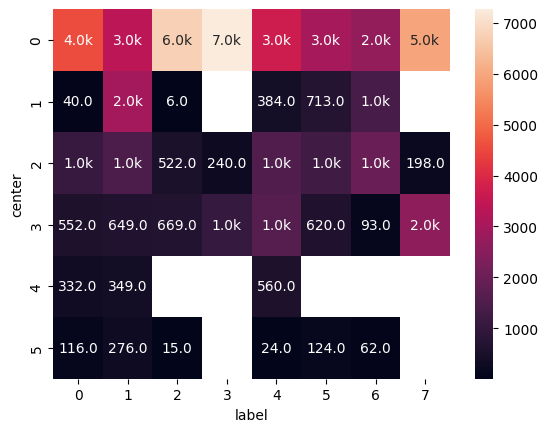

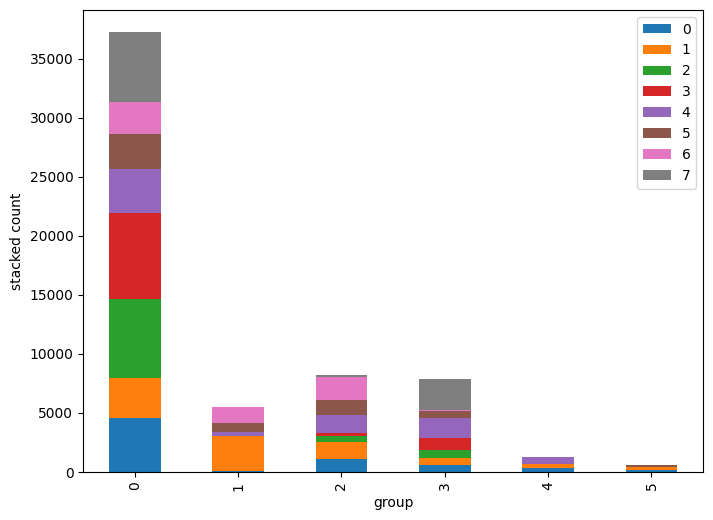

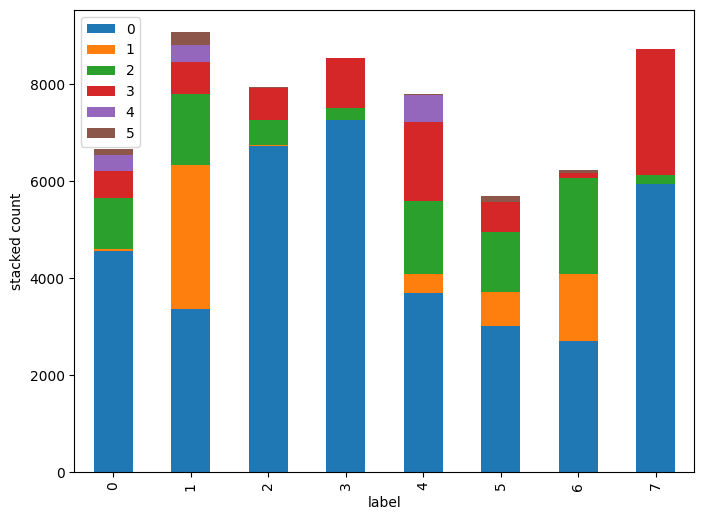

In [223]:
eda.twod_label_distribution(aug_data, 'label', GROUP_COL, LABELS)

In [224]:
import importlib

importlib.reload(eda)


<module 'eda_helpers' from '/home/kpetrenko/work/third_attempt/EDA/eda_helpers.py'>

In [228]:
import pickle
with open("/home/kpetrenko/work/data_skin/save_dataset.pkl", 'wb') as f:
    pickle.dump(aug_data, f)

In [ ]:
with open("/home/kpetrenko/work/data_skin/save_dataset.pkl", 'rb') as f:
    loaded_pickle = pickle.load(f)


,image,center,label
0,<PIL.Image.Image image mode=RGB size=128x128 a...,0,1
1,<PIL.Image.Image image mode=RGB size=128x128 a...,0,2
2,<PIL.Image.Image image mode=RGB size=128x128 a...,0,1
3,<PIL.Image.Image image mode=RGB size=128x128 a...,0,3
4,<PIL.Image.Image image mode=RGB size=128x128 a...,0,1


In [237]:
loaded_pickle.shape[0] / 128 * 0.7

331.97499999999997

/home/kpetrenko/work/third_attempt/EDA/eda_helpers.py:45: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_df = sns_feed.applymap(format_annotation)


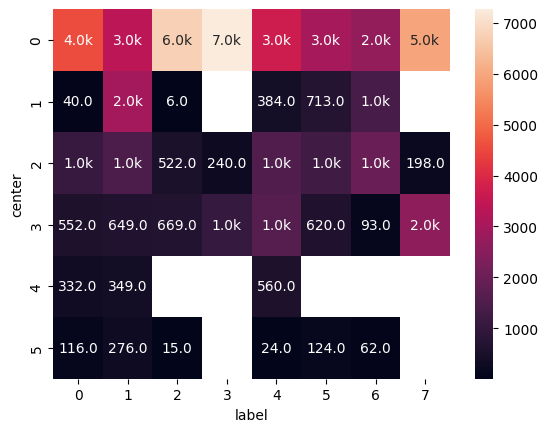

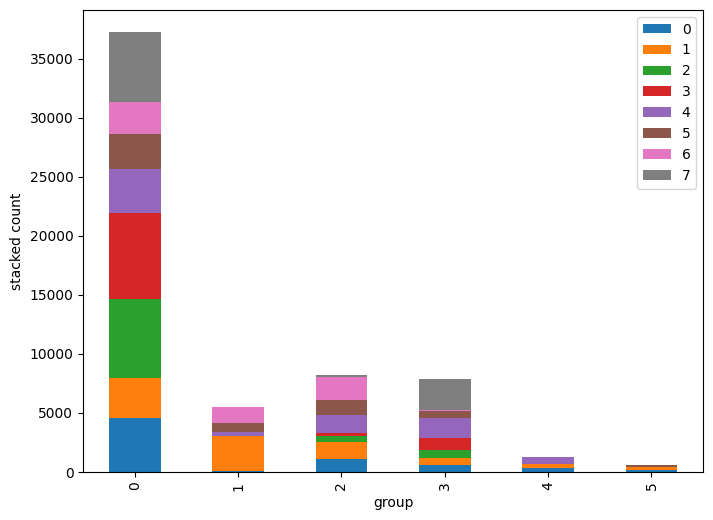

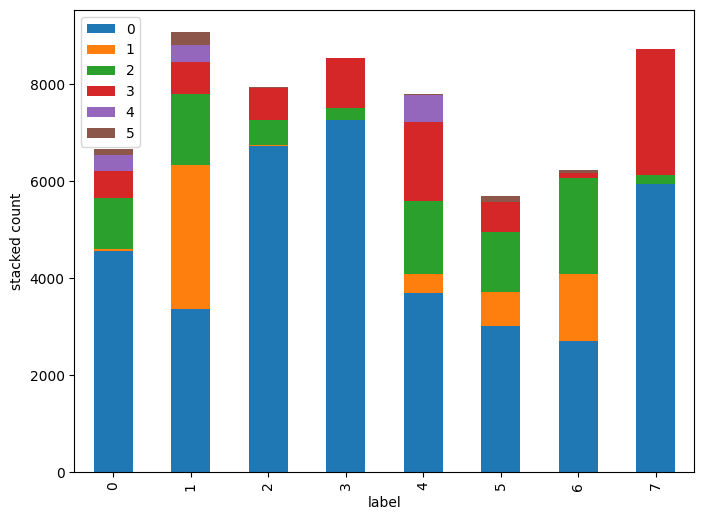

In [230]:
eda.twod_label_distribution(loaded_pickle, 'label', GROUP_COL, LABELS)